<a href="https://colab.research.google.com/github/sanketpund01/Movie_Recomendation_System/blob/main/Movie_Recommendation_Cosine_Similarity_Beginner_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Recommendation System using Cosine Similarity (Beginner)
A hard-coded 10-movie example using TF-IDF and Cosine Similarity.

In [1]:
import pandas as pd

movies={
"Movie":["Avatar","Titanic","The Avengers","Iron Man","The Dark Knight","Interstellar","Inception","The Notebook","Joker","Doctor Strange"],
"Genre":[
"Action Adventure Sci-Fi",
"Romance Drama",
"Action Adventure Superhero",
"Action Superhero Sci-Fi",
"Action Crime Drama",
"Adventure Sci-Fi Drama",
"Action Sci-Fi Thriller",
"Romance Drama",
"Crime Drama Thriller",
"Action Fantasy Sci-Fi"
]
}

df=pd.DataFrame(movies)
df


,Movie,Genre
0,Avatar,Action Adventure Sci-Fi
1,Titanic,Romance Drama
2,The Avengers,Action Adventure Superhero
3,Iron Man,Action Superhero Sci-Fi
4,The Dark Knight,Action Crime Drama
5,Interstellar,Adventure Sci-Fi Drama
6,Inception,Action Sci-Fi Thriller
7,The Notebook,Romance Drama
8,Joker,Crime Drama Thriller
9,Doctor Strange,Action Fantasy Sci-Fi


## TF-IDF Vectorization

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()
movie_vectors=tfidf.fit_transform(df["Genre"])
print(movie_vectors.shape)


(10, 10)


## Cosine Similarity

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

similarity=cosine_similarity(movie_vectors)

similarity_df=pd.DataFrame(similarity,index=df["Movie"],columns=df["Movie"])
similarity_df.round(2)


Movie,Avatar,Titanic,The Avengers,Iron Man,The Dark Knight,Interstellar,Inception,The Notebook,Joker,Doctor Strange
Movie,,,,,,,,,,
Avatar,1.00,0.00,0.54,0.61,0.20,0.80,0.61,0.00,0.00,0.57
Titanic,0.00,1.00,0.00,0.00,0.29,0.27,0.00,1.00,0.25,0.00
The Avengers,0.54,0.00,1.00,0.62,0.20,0.35,0.18,0.00,0.00,0.16
Iron Man,0.61,0.00,0.62,1.00,0.19,0.42,0.58,0.00,0.00,0.54
The Dark Knight,0.20,0.29,0.20,0.19,1.00,0.24,0.19,0.29,0.69,0.17
Interstellar,0.80,0.27,0.35,0.42,0.24,1.00,0.42,0.27,0.21,0.39
Inception,0.61,0.00,0.18,0.58,0.19,0.42,1.00,0.00,0.41,0.54
The Notebook,0.00,1.00,0.00,0.00,0.29,0.27,0.00,1.00,0.25,0.00
Joker,0.00,0.25,0.00,0.00,0.69,0.21,0.41,0.25,1.00,0.00


## Recommendation Function

In [4]:
def recommend(movie_name,n=5):
    scores=similarity_df[movie_name]
    return scores.sort_values(ascending=False).iloc[1:n+1]

recommend("Avatar")


,Avatar
Movie,
Interstellar,0.797223
Inception,0.609795
Iron Man,0.609795
Doctor Strange,0.565787
The Avengers,0.540955


In [5]:
recommend("Titanic")

,Titanic
Movie,
The Notebook,1.000000
The Dark Knight,0.291225
Interstellar,0.267918
Joker,0.253608
Avatar,0.000000


## Similarity Heatmap

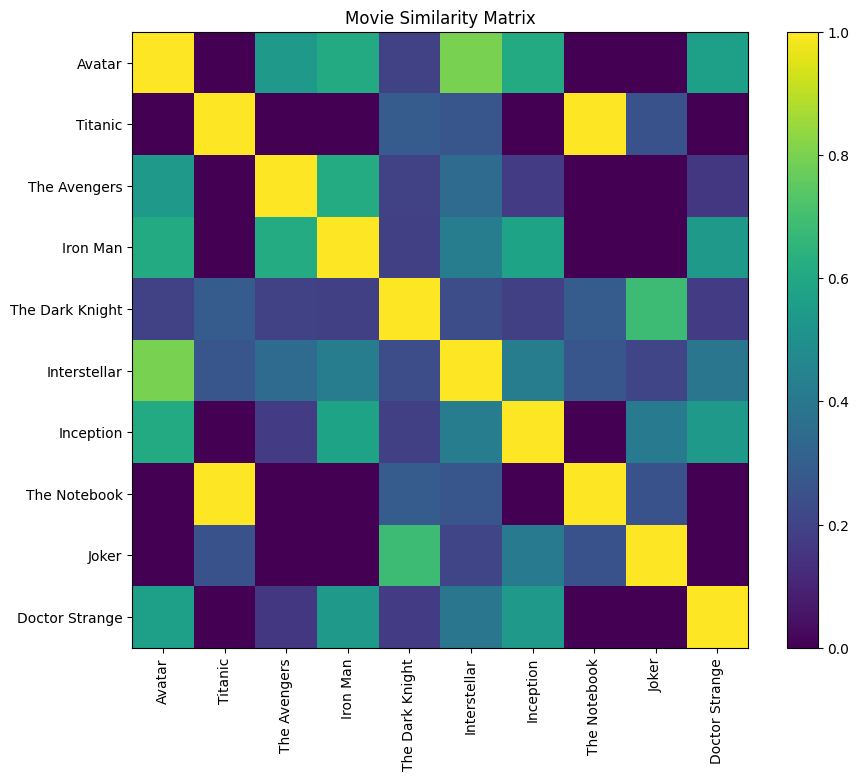

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(similarity_df,cmap='viridis')
plt.colorbar()
plt.xticks(range(len(df.Movie)),df.Movie,rotation=90)
plt.yticks(range(len(df.Movie)),df.Movie)
plt.title("Movie Similarity Matrix")
plt.show()
